In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import pickle
import deepRD.tools.trajectoryTools as trajectoryTools
import csv
import math
from deepRD.noiseSampler import noiseSampler
from torchvision.transforms import ToTensor
from torch import nn
from torch.utils.data import DataLoader
from sklearn.neighbors import KernelDensity
from sklearn.decomposition import PCA
from scipy.stats import wasserstein_distance_nd

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [3]:
class cvaeSampler(nn.Module):

    """
    Model for sampling of the interaction noise term in reduced simulations. 
    The model uses a Conditional Variational Autoencoder (CVAE) architecture.

    Parameters:
    latentDims (int): dimensionality of latent (encoded) space
    loadPretrained (str): filepath of pre-trained model to be loaded
    conditionedOn (str): ['piri', 'pipimri', etc.] - set of the variables used for conditioning of the decoding/encoding
    systemType (str): ['bistable', 'dimer']  
    
    
    hidden_dims (1-D array of int): e.g. [128, 64, 32] ; determines the encoder/decoder structure given as subsequent hidden layers
    norm_params = (mean_input, std_input, mean_cond, std_cond) (default: (0,1,0,1)): 
        mean and std of input and conditional distributions, for normalization/denormalization
    batch_norm (bool): if True, network is initialised with Batch Normalisation layers
    dropout (float: [0,1): dropout probability
    """

    def __init__(self, latentDims, loadPretrained, conditionedOn, systemType, hidden_dims=[128,64,32], batch_norm=False, 
                 dropout_rate=0, norm_params=(0,1,0,1), sampling_width=1, cutoff=False):
        
        super().__init__()
        self.conditionedOn = conditionedOn
        self.systemType = systemType
        self.latentDims = latentDims
        self.loadPretrained = loadPretrained
        self.conditionDims = self.getConditionDims()
        self.inputDims = self.getInputDims()
        self.G = torch.distributions.Normal(0, 1)
        self.sampling_width = sampling_width
        self.cutoff = cutoff
        
        if hidden_dims==None:
            # If hidden dims not given, initialising template network architecture
            fhl = 20

            self.encoder = nn.Sequential(
                nn.Linear(self.inputDims+self.conditionDims, 128),
                nn.ReLU(),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Linear(64, 40),
                nn.ReLU(),
                nn.Linear(40, 20),
                nn.ReLU()
            )
            
            self.decoder = nn.Sequential(
                nn.Linear(self.latentDims+self.conditionDims, 20),
                nn.ReLU(),
                nn.Linear(20, 40),
                nn.ReLU(),
                nn.Linear(40, 64),
                nn.ReLU(),
                nn.Linear(64, 128),
                nn.ReLU(),
                nn.Linear(128, self.inputDims)
            )

        else:
            # Building custom network architecture

            fhl = hidden_dims[-1]

            if dropout_rate>0 and batch_norm==True:
                print('Use either BN or Dropout, not both.')

            elif batch_norm: # Using Batch Norm only 
                self.encoder = nn.Sequential(
                nn.Linear(self.inputDims+self.conditionDims, hidden_dims[0]),
                nn.BatchNorm1d(hidden_dims[0]),
                nn.ReLU()
                )

                self.decoder = nn.Sequential(
                nn.Linear(self.latentDims+self.conditionDims, hidden_dims[-1]),
                nn.BatchNorm1d(hidden_dims[-1]),
                nn.ReLU()
                )

            else: # No BN
                
                self.encoder = nn.Sequential(
                nn.Linear(self.inputDims+self.conditionDims, hidden_dims[0]),
                nn.ReLU()
                )   

                self.decoder = nn.Sequential(
                nn.Linear(self.latentDims+self.conditionDims, hidden_dims[-1]),
                nn.ReLU()
                )

            for i in range(1, len(hidden_dims)):

                if dropout_rate>0:
                    self.encoder.append(nn.Dropout(dropout_rate))
                self.encoder.append(nn.Linear(hidden_dims[i-1], hidden_dims[i]))
                if batch_norm:
                    self.encoder.append(nn.BatchNorm1d(hidden_dims[i]))
                self.encoder.append(nn.ReLU())


                if dropout_rate>0:
                    self.decoder.append(nn.Dropout(dropout_rate))
                self.decoder.append(nn.Linear(hidden_dims[-i], hidden_dims[-(i+1)]))
                if batch_norm:
                    self.decoder.append(nn.BatchNorm1d(hidden_dims[-(i+1)]))
                self.decoder.append(nn.ReLU())

            self.decoder.append(nn.Linear(hidden_dims[0], self.inputDims))

        self.linear1 = nn.Linear(fhl, self.latentDims)
        self.linear2 = nn.Linear(fhl, self.latentDims)
        self.load_model() # Loading pre-trained weights.
        
        # Setting mean and std of input/conditional distributions, to normalize/renormalize during forward pass.
        self.mean_input, self.std_input, self.mean_cond, self.std_cond = norm_params


    def load_model(self):
        if self.loadPretrained==None:
            print('Untrained model initialized. Conditioned on:', self.conditionedOn)
        else:
            print('Loading pretrained model: ' + self.loadPretrained)
            self.load_state_dict(torch.load(self.loadPretrained))
            print('Model parameters loaded.')

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        return mu + std*self.G.sample(mu.shape).to(device)
    
    def normalize(self, x, mean, std):
        """
        Normalizes a tensor w.r.t a given mean and std.
        """
        return (x-mean.to(device))/std.to(device)

    def denormalize(self, x, mean, std):
        """
        Denormalizes a tensor w.r.t a given mean and std.
        """
        return x*std.to(device) + mean.to(device)
    
    
    def sample(self, label, num_samples=1):
        '''
         Here a slight workaround to get compatibility between model and integrator.
         Model is designed and trained to work on Torch tensors of size (num_samples, *), meanwhile 
         integrator works on 1-D arrays. 
         
         parameters:
         label (Torch Tensor or Numpy Array): conditioning variables.
         sampling_cutoff (bool): if True, any point sampled outside a pre-determined radius will be resampled

         Returns: 1-D Torch Tensor of size (input_dims)
        '''

        # Parameters for the Gaussian distribution used for sampling. 
        mean = 0
        std = self.sampling_width
        
        # Normalizing labels for inference
        label = self.normalize(label, self.mean_cond, self.std_cond)
        
        sim_sampling = True if isinstance(label, np.ndarray) else False

        if sim_sampling:

            with torch.no_grad():
                label = torch.from_numpy(label).float()
                
                if self.conditionedOn=="piri":
                    # Switching the order because models I trained with opposite order of cond. variables
                    r = label[3:]
                    v = label[:3]
                    label = torch.cat((r,v))
                        
        if label.dim()==1:
            label = label.unsqueeze(0)
            
        # Sampling latent space and decoding
        if not self.cutoff:
            samples = torch.normal(mean, std, (num_samples, self.latentDims))
            
        else:    
            samples = torch.zeros((num_samples, self.latentDims))
            for i in range(num_samples):
                while True:
                    zi = torch.normal(mean, std, (1, self.latentDims))
                    ri =  torch.linalg.vector_norm(zi)
                    if ri < 4:
                        break
                        
                samples[i] = zi[0]

        z_cond = torch.cat((samples, label), dim=1)
        out = self.decoder(z_cond).squeeze(0).detach().numpy() if sim_sampling else self.decoder(z_cond)
            
        # Denormalizing output
        out = self.denormalize(out, self.mean_input, self.std_input)

        return out

    def forward(self, x, y, returnLatent=False):
        
        # Preprocessing data
        x = self.normalize(x, self.mean_input, self.std_input)
        y = self.normalize(y, self.mean_cond, self.std_cond)
        
        # Passing through network
        x_cond = torch.cat((x,y), dim=1)
        x = self.encoder(x_cond)
        mu = self.linear1(x)
        logvar = self.linear2(x)
        z = self.reparametrize(mu, logvar)
        z_cond = torch.cat((z, y), dim=1)
        output = self.decoder(z_cond)
        
        # Denormalizing output to original form
        output = self.denormalize(output, self.mean_input, self.std_input)

        if returnLatent==True:
            return output, mu, logvar, z
        
        return output, mu, logvar
    
    def getConditionDims(self):

        if self.systemType=='bistable':    
            if self.conditionedOn=="piri":
                return 6
            elif self.conditionedOn=="piririm":
                return 9
            elif self.conditionedOn=="piripim":
                return 9
            elif self.conditionedOn=="piririmpim":
                return 12
            else:
                print('Unsupported model type')
                return None

        elif self.systemType=='dimer':    
            if self.conditionedOn=="piri":
                return 12
            elif self.conditionedOn=="piridqi":
                return 13
            else:
                print('Unsupported model type')
                return None

    def getInputDims(self):

        if self.systemType=='bistable':
            return 3
        elif self.systemType=='dimer':
            return 6

In [4]:
class Annealer:
    """
    This class is used to anneal the KL divergence loss over the course of training VAEs.
    After each call, the step() function should be called to update the current epoch.
    """

    def __init__(self, total_steps, shape, baseline=0.0, cyclical=False, disable=False):
        """
        Parameters:
            total_steps (int): Number of epochs to reach full KL divergence weight.
            shape (str): Shape of the annealing function. Can be 'linear', 'cosine', or 'logistic'.
            baseline (float): Starting value for the annealing function [0-1]. Default is 0.0.
            cyclical (bool): Whether to repeat the annealing cycle after total_steps is reached.
            disable (bool): If true, the __call__ method returns unchanged input (no annealing).
        """
        self.total_steps = total_steps
        self.current_step = 0
        self.cyclical = cyclical
        self.shape = shape
        self.baseline = baseline
        if disable:
            self.shape = 'none'
            self.baseline = 0.0

    def __call__(self, kld):
        """
        Args:
            kld (torch.tensor): KL divergence loss
        Returns:
            out (torch.tensor): KL divergence loss multiplied by the value (slope) of the annealing function.
        """
        out = kld * self.slope()
        return out

    def slope(self):
        if self.shape == 'linear':
            y = (self.current_step / self.total_steps)
        elif self.shape == 'cosine':
            y = (math.cos(math.pi * (self.current_step / self.total_steps - 1)) + 1) / 2
        elif self.shape == 'logistic':
            exponent = ((self.total_steps / 2) - self.current_step)
            y = 1 / (1 + math.exp(exponent))
        elif self.shape == 'none':
            y = 1.0
        else:
            raise ValueError('Invalid shape for annealing function. Must be linear, cosine, or logistic.')
        y = self.add_baseline(y)
        return y

    def step(self):
        if self.current_step < self.total_steps:
            self.current_step += 1
        if self.cyclical and self.current_step >= self.total_steps:
            self.current_step = 0
        return

    def add_baseline(self, y):
        y_out = y * (1 - self.baseline) + self.baseline
        return y_out

    def cyclical_setter(self, value):
        if value is not bool:
            raise ValueError('Cyclical_setter method requires boolean argument (True/False)')
        else:
            self.cyclical = value
        return

In [5]:
# Defining loss functions 
loss_1 = nn.MSELoss()
def loss_2(mu, logvar):
    return torch.mean(-0.5 * torch.sum(1 + logvar - mu ** 2 - torch.exp(logvar), dim = 1), dim = 0)#.sum()

In [6]:
def modelTraining(data_loader, epochs, beta1, beta2, test_data_loader):
    
    '''
    Function to train the CVAE
    
    Parameters:
    data_loader (PyTorch DataLoader object with training data)
    test_data_loader (Test/Validation Data)
    epochs(int): number of epochs
    
    beta1 (normally set to 1)
    beta2: KL Divergence term, regularization.
    '''
    
    return_reconstructions = False
    losses = []
    losses_PE = []
    r_norms = None
    r_new = None

    # Instantiating annealing agent
    annealing_period = 10
    annealing_agent = Annealer(annealing_period, shape='logistic', cyclical=True, disable=False)
    
    for epoch in range(epochs):
        VAE.train()
        r_epoch = None
        
        # Saving loss both per-batch and total (average) loss
        val_loss = 0
        total_loss = 0
        total_l1 = 0
        total_l2 = 0
        bc = 0 # counting batches to calculate per-batch error

        # At the start of epoch, evaluate validation error.
        for (image_t, label_t) in test_data_loader:
            bc += 1
            image_t, label_t = image_t.to(device), label_t.to(device)
            reconstruction_t, mu_t, logvar_t = VAE(image_t, label_t)
            val_loss += loss_1(reconstruction_t, image_t).item() # MSE loss only on validation set

        val_loss /= bc # recover average per-batch loss
        bc = 0 # reset batch counter
        
        for (image, label) in data_loader:
            bc += 1
            
            image, label = image.to(device), label.to(device)
            
            # Feed through the network
            reconstruction, mu, logvar = VAE(image, label)
            # Calculate loss function
            l1 = loss_1(reconstruction, image)
            l2 = loss_2(mu, logvar)
            l2 = annealing_agent(l2)

            loss = beta1*l1 + beta2*l2
            
            # [Total Loss, MSE Loss, KL Div Loss, Validation Loss]
            losses.append([loss.item(), beta1*l1.item(), beta2*l2.item(), val_loss])
            
            total_loss += loss.item()
            total_l1 += l1.item()
            total_l2 += l2.item()
    
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


            if return_reconstructions:
                with torch.no_grad():
                    if r_epoch is None:
                        r_epoch = reconstruction
                    else:
                        r_epoch = torch.cat( (r_epoch, reconstruction), dim=0)
                        
        annealing_agent.step()
        losses_PE.append([total_l1/bc, total_l2*beta2/bc, total_loss/bc, val_loss])
        print(f'E{epoch+1}, MSE: {round(losses_PE[-1][0]*1000,4)}, KLD: {round(losses_PE[-1][1]*1000,4)}, TOT: {round(losses_PE[-1][2]*1000,4)} VAL: {round(losses_PE[-1][3]*1000,4)}')
    return r_epoch, losses, losses_PE

In [71]:
# System type: 'bistable', 'dimer'
systemType = 'bistable'

# Conditioning variables: piri, piririm, pipimri, etc. - for dimer, piridqi
conditionedOn = 'piri'

# datapoint = [time (1), qi (3), vi (3), ? (1), ri(3)] -- 11 dim
# for dimer, alternating between particle 1 and particle 2.

# Datasets directory
localDirectory = "/group/ag_cmb/scratch/maojrs/stochasticClosure/" + systemType + "/boxsize5/benchmark/"

# Total no. of datasets
n_datasets = 200
train_split = 0.8

# Sample simulation files randomly
fnums = np.random.choice(2500, n_datasets, replace=False)
#print(fnums)
dataset = None

for f_num in fnums:
    try:
        ds = torch.Tensor(trajectoryTools.loadTrajectory(localDirectory + "simMoriZwanzig_", f_num)).unsqueeze(0)
    except FileNotFoundError:
        print(f'File {f_num} not available.')
        continue
              
    if dataset is None:
        dataset = ds
    else:
        dataset = torch.cat((dataset, ds), dim=0)

# Dataset - training data
dataset.shape
#print(dataset[0, :6])

torch.Size([200, 10000, 11])

In [70]:
TT_split = 0.2 # set value for test-train split

# Number of datasets for training
n_datasets = dataset.shape[0]

if systemType=='bistable':

    # Extracting desired vectors from dataset
    r_aux = dataset[:, :, -3:] 
    r_nxt = torch.roll(r_aux, -1, 1)
    r_prev = torch.roll(r_aux, 1, 1)
    v = dataset[:, :, 4:7]
    v_prev = torch.roll(v, 1, 1)

    # Cut out first & last datapoint for consistency
    r_aux = r_aux[:, 1:-1].flatten(end_dim=1)
    r_nxt = r_nxt[:, 1:-1].flatten(end_dim=1)
    r_prev = r_prev[:, 1:-1].flatten(end_dim=1)
    v = v[:, 1:-1].flatten(end_dim=1)
    v_prev = v_prev[:, 1:-1].flatten(end_dim=1)


    # Split data: first 20% test, remaining 80% test.
    split_ind = int(TT_split*len(r_aux))

    # Build labels tensor
    if conditionedOn=="piri":
        conditionalVars = torch.cat((r_aux, v), dim = 1)
    elif conditionedOn=="piririm":
        conditionalVars = torch.cat((v, r_aux, r_prev), dim = 1)
    elif conditionedOn=="pipimri":
        conditionalVars = torch.cat((v, v_prev, r_aux), dim = 1)
    else:
        print('Invalid model type.')

    inputVars = r_nxt


elif systemType=='dimer':
    # Extracting desired vectors from dataset

    # Particle 1
    q1 = dataset[:, ::2, 1:4] # q_n
    r_aux1 = dataset[:, ::2, -3:] # r_n
    r_nxt1 = torch.roll(r_aux1, -1, 1) # r_n+1
    r_prev1 = torch.roll(r_aux1, 1, 1) # r_n-1
    v1 = dataset[:, ::2, 4:7] # v_n
    v_prev1 = torch.roll(v1, 1, 1) # v_n-1

    # Particle 2
    q2 = dataset[:, 1::2, 1:4] # q_n
    r_aux2 = dataset[:, 1::2, -3:] # r_n
    r_nxt2 = torch.roll(r_aux2, -1, 1) # r_n+1
    r_prev2 = torch.roll(r_aux2, 1, 1) # r_n-1
    v2 = dataset[:, 1::2, 4:7] # v_n
    v_prev2 = torch.roll(v2, 1, 1) # v_n-1

    # Cut out first & last datapoint for consistency
    q1 = q1[:, 1:-1].flatten(end_dim=1)
    r_aux1 = r_aux1[:, 1:-1].flatten(end_dim=1)
    r_nxt1 = r_nxt1[:, 1:-1].flatten(end_dim=1)
    r_prev1 = r_prev1[:, 1:-1].flatten(end_dim=1)
    v1 = v1[:, 1:-1].flatten(end_dim=1)
    v_prev1 = v_prev1[:, 1:-1].flatten(end_dim=1)

    q2 = q2[:, 1:-1].flatten(end_dim=1)
    r_aux2 = r_aux2[:, 1:-1].flatten(end_dim=1)
    r_nxt2 = r_nxt2[:, 1:-1].flatten(end_dim=1)
    r_prev2 = r_prev2[:, 1:-1].flatten(end_dim=1)
    v2 = v2[:, 1:-1].flatten(end_dim=1)
    v_prev2 = v_prev2[:, 1:-1].flatten(end_dim=1)
    
    # Computing relative distance
    dq = np.zeros(q1.shape)
    for i in range(q1.shape[0]):
        dq[i] = trajectoryTools.relativePosition(q1[i], q2[i], 'periodic', 5)
        
    dq = torch.from_numpy(np.linalg.norm(dq, axis=1)).unsqueeze(1).float()
    
    if conditionedOn == 'piridqi':
        conditionalVars = torch.cat((v1, v2, r_aux1, r_aux2, dq), dim = 1) # pi1, pi2, ri1, ri2, dq
    else:
        print('Invalid model type')

    inputVars = torch.cat( (r_nxt1, r_nxt2), dim = 1)

    
normalize_data=True

if normalize_data:
    print('Estimating mean and std for subsets')
    cuts = np.linspace(2, inputVars.shape[0], num=10).astype(int)

    for i, p in enumerate(cuts):
        p_inds = np.random.choice(inputVars.shape[0], p, replace=False)
        mean_input, std_input = torch.mean(inputVars[:p], dim=0), torch.std(inputVars[:p], dim=0)
        mean_cond, std_cond = torch.mean(conditionalVars[:p], dim=0), torch.std(conditionalVars[:p], dim=0)
        print(f'{i+1}:', std_cond,'\n')
    
    # Calculating mean and std of input and conditional distributions.
    mean_input, std_input = torch.mean(inputVars, dim=0), torch.std(inputVars, dim=0)
    mean_cond, std_cond = torch.mean(conditionalVars, dim=0), torch.std(conditionalVars, dim=0)
    #mean_input, std_input, mean_cond, std_cond = (torch.tensor([ 5.2723e-06,  3.6534e-06, -4.3195e-06]), torch.tensor([0.0162, 0.0162, 0.0162]), torch.tensor([ 5.1132e-06,  3.7120e-06, -4.3634e-06,  1.0060e-04, -9.1961e-05, 1.0791e-05]), torch.tensor([0.0162, 0.0162, 0.0162, 0.1425, 0.1426, 0.1425]))

else:
    mean_input, std_input, mean_cond, std_cond = (torch.tensor(0),torch.tensor(1),torch.tensor(0),torch.tensor(1))
    
# Split data: first 20% test, remaining 80% test.
split_ind = int(TT_split*len(inputVars))

# Build Train and Test Datasets
test_data = torch.utils.data.TensorDataset(inputVars[:split_ind], conditionalVars[:split_ind])
data = torch.utils.data.TensorDataset(inputVars[split_ind:], conditionalVars[split_ind:])

inputVars.shape, conditionalVars.shape, len(test_data), len(data)

Estimating mean and std for subsets
1: tensor([9.6206e-05, 4.7465e-03, 4.2458e-03, 3.0072e-05, 1.4802e-03, 3.9291e-03]) 

2: tensor([0.0162, 0.0162, 0.0162, 0.1424, 0.1431, 0.1423]) 

3: tensor([0.0162, 0.0162, 0.0162, 0.1426, 0.1429, 0.1423]) 

4: tensor([0.0162, 0.0162, 0.0162, 0.1424, 0.1427, 0.1424]) 

5: tensor([0.0162, 0.0162, 0.0162, 0.1425, 0.1425, 0.1425]) 

6: tensor([0.0162, 0.0162, 0.0162, 0.1425, 0.1426, 0.1426]) 

7: tensor([0.0162, 0.0162, 0.0162, 0.1426, 0.1425, 0.1425]) 

8: tensor([0.0162, 0.0162, 0.0162, 0.1426, 0.1425, 0.1426]) 

9: tensor([0.0162, 0.0162, 0.0162, 0.1426, 0.1425, 0.1426]) 

10: tensor([0.0162, 0.0162, 0.0162, 0.1425, 0.1425, 0.1426]) 



(torch.Size([24995000, 3]), torch.Size([24995000, 6]), 4999000, 19996000)

In [32]:
# Model settings
localModelDirectory = '/home/mi/jakut77/cgr/deepRD/deepRD/noiseSampler/models/'

# Load a pretrained Model or None to initialise random
loadPretrained = None
#loadPretrained = localModelDirectory + 'modelWeights/model_state_' + conditionedOn + '_E81.pt'

hiddenDims=[128,64,32]
latentDims=8

batch_norm=False
dropout_rate=0
cutoff = True

# Set to false if you want to continue training model here.
initialize_model = False

if initialize_model:

    VAE = cvaeSampler(latentDims, loadPretrained, conditionedOn, systemType, hidden_dims=hiddenDims, 
                      batch_norm=batch_norm, dropout_rate=dropout_rate, 
                      norm_params=(mean_input, std_input, mean_cond, std_cond), cutoff=cutoff)
    VAE = VAE.to(device)
    
    # Saving losses
    f = open(localModelDirectory+"modelLosses/losses_nb.csv", "w")
    f.truncate()
    f.close()
    
else:
    print('Continuing with existing model.')

# Training parameters
n_epochs = 40
batch_size = 32
# beta1 - MSE Loss, beta2 - KL Div Loss Maximum Value.
beta1 = 1 #10
beta2 = 1e-5 #5e-5#2e-5

# Load dataset into DataLoader, shuffle
data_loader = DataLoader(data, batch_size=batch_size, shuffle=True)
test_data_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

# Optimizer parameters:
learning_rate = 1e-4
weight_decay = 0 #1e-6 #1e-8

optimizer = torch.optim.Adam(VAE.parameters(),
                             lr = learning_rate,
                             weight_decay = weight_decay)

Continuing with existing model.


In [20]:
# Training data is used for fitting
_, losses, epoch_losses = modelTraining(data_loader, n_epochs, beta1, beta2, test_data_loader)

E1, MSE: 0.0132, KLD: 0.0021, TOT: 0.0153 VAL: 0.2654
E2, MSE: 0.0009, KLD: 0.0026, TOT: 0.0035 VAL: 0.0007
E3, MSE: 0.0013, KLD: 0.0043, TOT: 0.0056 VAL: 0.0008
E4, MSE: 0.0026, KLD: 0.0074, TOT: 0.01 VAL: 0.0011
E5, MSE: 0.005, KLD: 0.0114, TOT: 0.0164 VAL: 0.0027
E6, MSE: 0.0084, KLD: 0.0146, TOT: 0.023 VAL: 0.0048
E7, MSE: 0.0114, KLD: 0.0166, TOT: 0.028 VAL: 0.0083
E8, MSE: 0.0131, KLD: 0.0175, TOT: 0.0306 VAL: 0.012
E9, MSE: 0.0139, KLD: 0.0177, TOT: 0.0315 VAL: 0.0132
E10, MSE: 0.0142, KLD: 0.0176, TOT: 0.0318 VAL: 0.014
E11, MSE: 0.0007, KLD: 0.0006, TOT: 0.0014 VAL: 0.0137
E12, MSE: 0.0005, KLD: 0.0014, TOT: 0.0019 VAL: 0.0003
E13, MSE: 0.0009, KLD: 0.003, TOT: 0.0039 VAL: 0.0005
E14, MSE: 0.002, KLD: 0.0058, TOT: 0.0078 VAL: 0.0009
E15, MSE: 0.0044, KLD: 0.0096, TOT: 0.014 VAL: 0.0022
E16, MSE: 0.0076, KLD: 0.0135, TOT: 0.021 VAL: 0.0044
E17, MSE: 0.0106, KLD: 0.0159, TOT: 0.0264 VAL: 0.008
E18, MSE: 0.0124, KLD: 0.0169, TOT: 0.0294 VAL: 0.0107
E19, MSE: 0.0134, KLD: 0.0171, 

In [21]:
# SAVING LOSSES
with open(localModelDirectory+'modelLosses/losses_nb.csv', 'a', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerows(epoch_losses)

In [22]:
# READING LOSS FILE
losses_sum = []
losses_1 = []
losses_2 = []
losses_val = []

#Name of loss file to read
loss_filename = 'losses_nb.csv'

with open(localModelDirectory+'modelLosses/'+loss_filename, mode ='r') as file:    
       csvFile = csv.reader(file)
       for line in csvFile:
           losses_1.append(float(line[0]))
           losses_2.append(float(line[1]))
           losses_sum.append(float(line[2]))
           losses_val.append(float(line[3]))

losses_val = list(dict.fromkeys(losses_val))
len(losses_sum), len(losses_val)#, len(epoch_losses)

(40, 40)

1.3724606542879073e-05 1.6223745901993834e-05 2.9948352058330942e-05 1.3409252302517417e-05


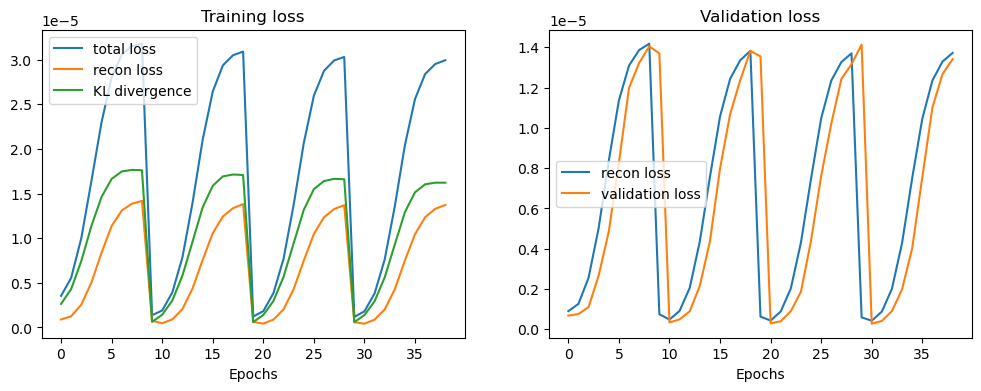

In [23]:
# PLOTTING LOSS
#plt.style.use('fivethirtyeight')

# Cut out first X epochs from the plot
plt_split = 1

fig = plt.figure(figsize=(12,4))

# Plotting the last 100 values for training loss
ax1 = fig.add_subplot(1,2,1)
ax1.plot(losses_sum[plt_split:], label='total loss')
#ax1.plot(losses_sum[:plt_split], label='first 100')
ax1.plot(losses_1[plt_split:], label='recon loss')
ax1.plot(np.array(losses_2[plt_split:]), label='KL divergence')
ax1.set_xlabel('Epochs')
ax1.set_title('Training loss')
ax1.legend()

ax2 = fig.add_subplot(1,2,2)
ax2.plot(losses_1[plt_split:], label='recon loss')
ax2.plot(losses_val[plt_split:], label='validation loss')
#ax2.plot(np.array(epoch_losses[-100:])/20, label='epoch-wise loss')
ax2.set_xlabel('Epochs')
ax2.set_title('Validation loss');
ax2.legend()
print(losses_1[-1], losses_2[-1], losses_sum[-1], losses_val[-1])

In [36]:
# Using test data to validate the model, by reconstructing and generating new samples.
inds = np.arange(len(test_data))

labels = test_data[:][1]
images = test_data[:][0]

with torch.no_grad():
        
    # Generating latent encodings and reconstructions for test set
    r_new, _, _, z = VAE(images, labels, returnLatent=True)
    z_prior = np.random.multivariate_normal([0,0], [[1,0], [0,1]], len(inds))
    
    # Generating samples
    generated = VAE.sample(labels, num_samples=len(labels))
    
    # The above returns r_aux if bistable, (r_aux1, r_aux2) if dimer
    
    if systemType=='bistable':
        
        # Data distributions for r_n and r_n+1
        r_aux1 = labels[:, :3]
        v1 = labels[:, 3:]
        r_nxt1 = torch.roll(r_aux, -1, 0)
        
        r_new1 = r_new # Reconstructions of test data
        generated1 = generated # Generated samples with test labels

    elif systemType=='dimer':
        r_new1 = r_new[:, :3]
        r_new2 = r_new[:, 3:]

        generated1 = generated[:, :3]
        generated2 = generated[:, 3:]
        
    print(labels.shape, z.shape, generated.shape, r_new.shape, z_prior.shape, v_1.shape)
 

torch.Size([79984, 6]) torch.Size([79984, 8]) torch.Size([79984, 3]) torch.Size([79984, 3]) (79984, 2) torch.Size([79984, 3])


In [25]:
# Loading binning model for sampling and comparison.

print("Loading binned data ...")

binnedDataFilename = '/group/ag_cmb/scratch/maojrs/stochasticClosure/' + systemType + '/boxsize5/binnedData/' + conditionedOn + 'BinnedData.pickle'
dataOnBins = pickle.load(open(binnedDataFilename, "rb" ))
parameters = dataOnBins.parameterDictionary
print('Binned data loaded')

nSampler = noiseSampler(dataOnBins)

Loading binned data ...
Binned data loaded


In [26]:
# Sampling with the binning model.

generated_bin = np.zeros(generated.shape)
for i, label in enumerate(labels):
    generated_bin[i] = nSampler.sample(label)
    
generated_bin.shape

(79984, 3)

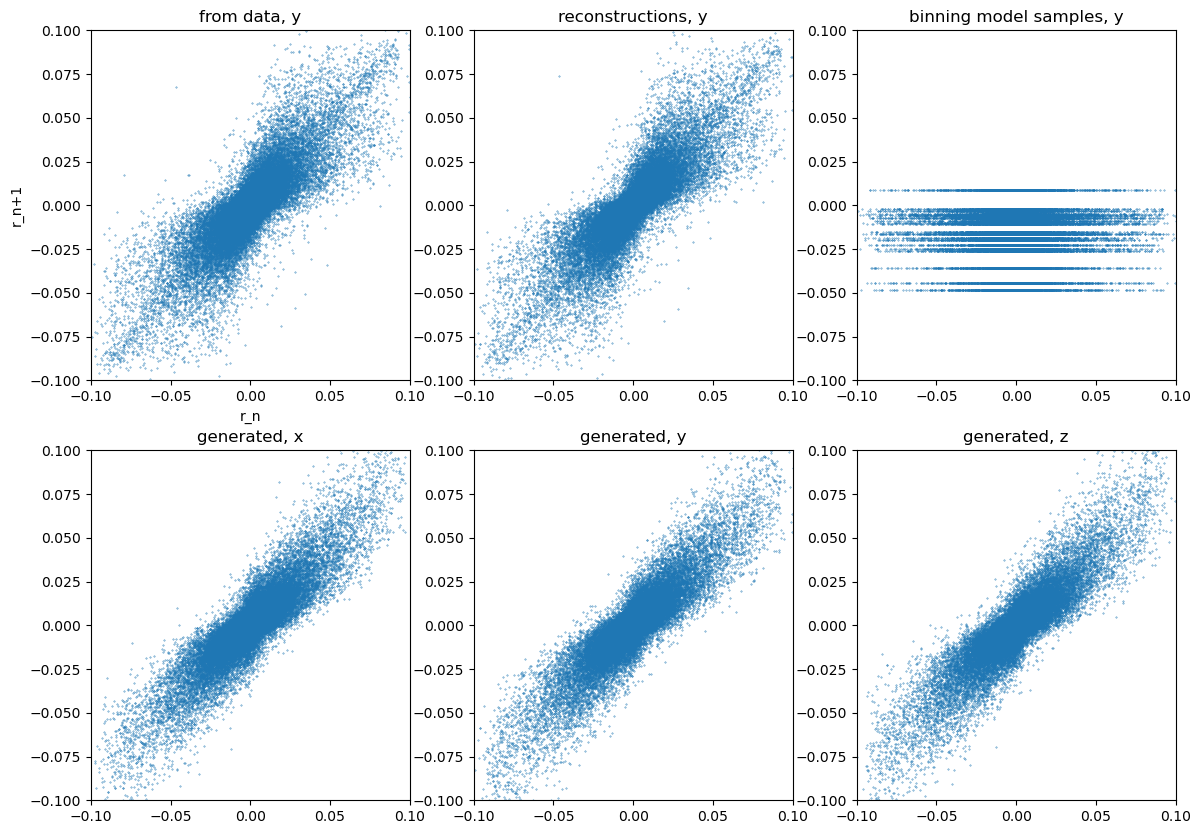

In [72]:
dim_labels = ['x', 'y', 'z']
dim_index = 1 # choose which dimension to plot
ax_lim = 0.10

# The following plots show the distribution r_n+1 | r_n.

fig = plt.figure(figsize=(14,10))

ax1 = fig.add_subplot(2,3,1)
ax1.scatter(r_aux1[inds, dim_index], r_nxt1[inds, dim_index], s=0.1)
ax1.set_xlabel('r_n')
ax1.set_ylabel('r_n+1')
ax1.set_title(f'from data, {dim_labels[dim_index]}')
ax1.set_xlim([-ax_lim,ax_lim])
ax1.set_ylim([-ax_lim,ax_lim])

ax2 = fig.add_subplot(2,3,2, sharex=ax1, sharey=ax1)
ax2.scatter(r_aux1[inds, dim_index], r_new1[inds, dim_index], s=0.1)
#ax2.scatter(z_prior[:,0], z_prior[:,1], s=0.5, alpha=0.2)
ax2.set_title(f'reconstructions, {dim_labels[dim_index]}')

ax3 = fig.add_subplot(2,3,3, sharex=ax1, sharey=ax1)
ax3.set_title(f'binning model samples, {dim_labels[dim_index]}')
ax3.scatter(r_aux1[inds, dim_index], generated_bin[inds, dim_index], s=0.1)

ax4 = fig.add_subplot(2,3,4, sharex=ax2, sharey=ax2)
ax4.scatter(r_aux1[inds, 0], generated1[inds, 0], s=0.1)
ax4.set_title('generated, x')

ax5 = fig.add_subplot(2,3,5, sharex=ax2, sharey=ax2)
ax5.scatter(r_aux1[inds, 1], generated1[inds, 1], s=0.1)
ax5.set_title('generated, y')

ax6 = fig.add_subplot(2,3,6, sharex=ax2, sharey=ax2)
ax6.scatter(r_aux1[inds, 2], generated1[inds, 2], s=0.1)
ax6.set_title('generated, z')

fig.show()

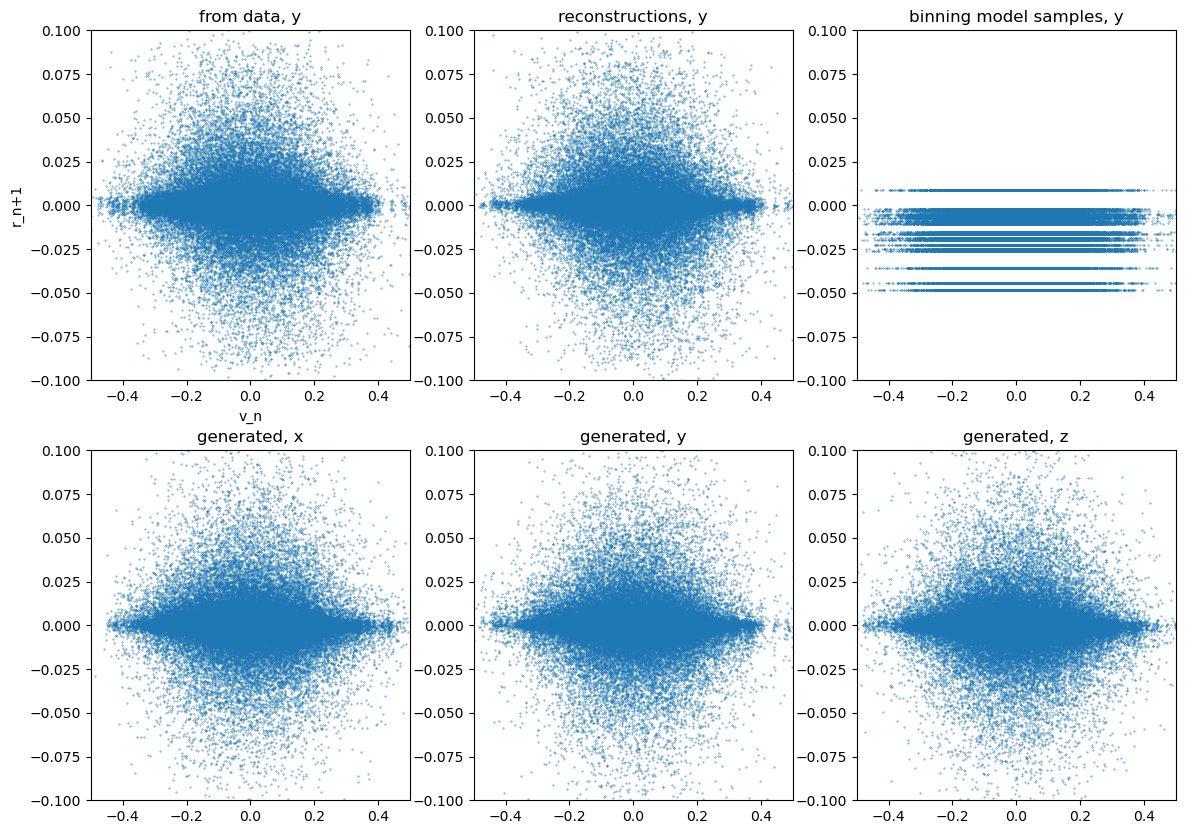

In [73]:
# The following plots show the distribution r_n+1 | v_n.

fig = plt.figure(figsize=(14,10))

ax1 = fig.add_subplot(2,3,1)
ax1.scatter(v1[inds, dim_index], r_nxt1[inds, dim_index], s=0.1)
ax1.set_xlabel('v_n')
ax1.set_ylabel('r_n+1')
ax1.set_title(f'from data, {dim_labels[dim_index]}')
ax1.set_xlim([-5*ax_lim,5*ax_lim])
ax1.set_ylim([-ax_lim,ax_lim])

ax2 = fig.add_subplot(2,3,2, sharex=ax1, sharey=ax1)
ax2.scatter(v1[inds, dim_index], r_new1[inds, dim_index], s=0.1)
ax2.set_title(f'reconstructions, {dim_labels[dim_index]}')

ax3 = fig.add_subplot(2,3,3, sharex=ax1, sharey=ax1)
ax3.set_title(f'binning model samples, {dim_labels[dim_index]}')
ax3.scatter(v1[inds, dim_index], generated_bin[inds, dim_index], s=0.1)

ax4 = fig.add_subplot(2,3,4, sharex=ax2, sharey=ax2)
ax4.scatter(v1[inds, 0], generated1[inds, 0], s=0.1)
ax4.set_title('generated, x')

ax5 = fig.add_subplot(2,3,5, sharex=ax2, sharey=ax2)
ax5.scatter(v1[inds, 1], generated1[inds, 1], s=0.1)
ax5.set_title('generated, y')

ax6 = fig.add_subplot(2,3,6, sharex=ax2, sharey=ax2)
ax6.scatter(v1[inds, 2], generated1[inds, 2], s=0.1)
ax6.set_title('generated, z')

fig.show()

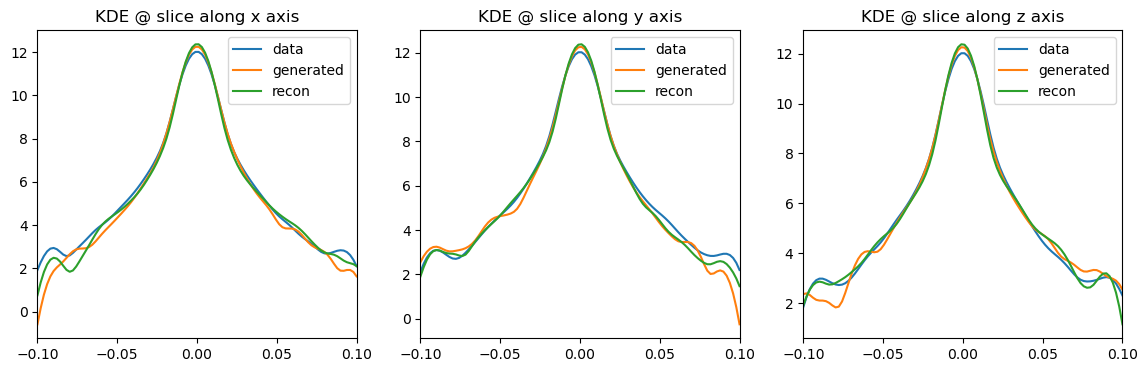

In [74]:
# Kernel Density Estimation - 3-dimensional fit (x,y,z)
axe_lim = 0.1

# Original data
kde1 = KernelDensity(bandwidth=0.005)
kde1.fit(r_nxt1)

# Generated data
kde2 = KernelDensity(bandwidth=0.005)
kde2.fit(generated1);

# Binning model samples - for comparison
kde3 = KernelDensity(bandwidth=0.005)
kde3.fit(generated_bin)

# Reconstructed data - not necessarily interesting (?)
kde4 = KernelDensity(bandwidth=0.005)
kde4.fit(r_new1)


# Draw grid
num_gridpts = 100
grid_1d = np.linspace(-axe_lim, axe_lim, num_gridpts)
c_yz = 0.0
E = np.full((num_gridpts,2), c_yz)
grid_slice = np.concatenate((grid_1d[:, np.newaxis], E), axis=1)

fig = plt.figure(figsize=(14,4))

for i, dim in enumerate(dim_labels):
    
    grid_slice = np.insert(E, i, grid_1d, axis=1)

    # Evaluate KDE on grid slice
    pdf_data = kde1.score_samples(grid_slice)
    #pdf_rec = kde2.score_samples(grid_1d.reshape(-1,1))
    pdf_gen = kde2.score_samples(grid_slice)
    #pdf_bin = kde3.score_samples(grid_slice)
    pdf_rec = kde4.score_samples(grid_slice)

    # Plotting 3D KDE evaluation at (x, 0, 0)
    ax = fig.add_subplot(1,3,i+1)
    ax.plot(grid_slice[:,i], pdf_data, label='data')
    ax.plot(grid_slice[:,i], pdf_gen, label='generated')
    #ax.plot(grid_slice[:,i], pdf_bin, label='binning')
    ax.plot(grid_slice[:,i], pdf_rec, label='recon')
    ax.set_title(f'KDE @ slice along {dim} axis')
    ax.set_xlim([-axe_lim, axe_lim])
    ax.legend()
    
fig.show()

In [75]:
# Evaluating KDE on a 3D grid (with less points per dimension due to computational requirements)
numpts_per_dim = 20 # this gives 20^3 = 8000 pts

grid_reduced = np.linspace(-axe_lim, axe_lim, numpts_per_dim)
grid_3d = np.array([[x, y, z] for x in grid_reduced for y in grid_reduced for z in grid_reduced])
grid_3d.shape, grid_slice.shape

pdf_data_3d = kde1.score_samples(grid_3d)
pdf_gen_3d = kde2.score_samples(grid_3d)
pdf_bin_3d = kde3.score_samples(grid_3d)
pdf_rec_3d = kde4.score_samples(grid_3d)

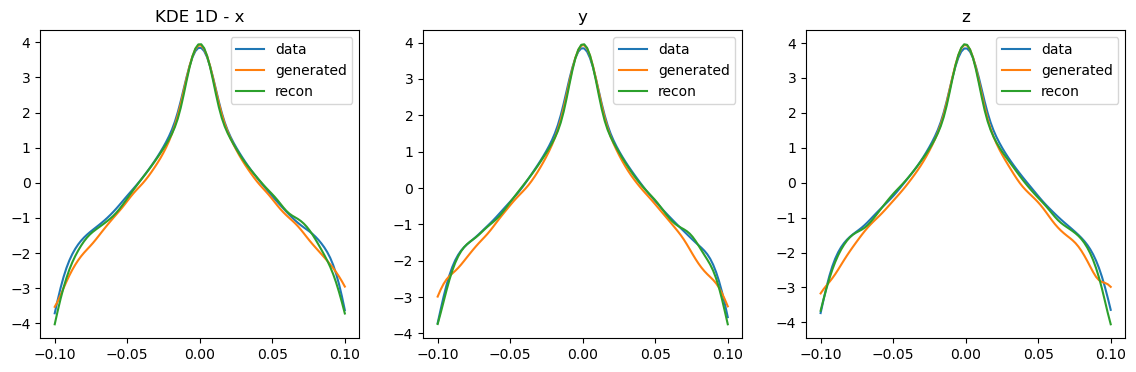

In [76]:
plot_labels = ['data', 'generated', 'recon']
plot_titles = ['KDE 1D - x', 'y', 'z']

fig = plt.figure(figsize=(14,4))

for i in range(len(plot_titles)):
    
    # Kernel Density Estimation - extracting 1 coordinate
    
    # Original data
    kde1_1d = KernelDensity(bandwidth=0.005)
    kde1_1d.fit(r_nxt1[:, i].reshape(-1,1))
    
    # Generated data
    kde2_1d = KernelDensity(bandwidth=0.005)
    kde2_1d.fit(generated1[:, i].reshape(-1,1));
    
    # Binning model
    kde3_1d = KernelDensity(bandwidth=0.005)
    kde3_1d.fit(generated_bin[:, i].reshape(-1,1));
    
    # Reconstructions
    kde4_1d = KernelDensity(bandwidth=0.005)
    kde4_1d.fit(r_new1[:, i].reshape(-1,1));
    
    pdf_data_1d = kde1_1d.score_samples(grid_1d.reshape(-1,1))
    pdf_gen_1d = kde2_1d.score_samples(grid_1d.reshape(-1,1))
    pdf_bin_1d = kde3_1d.score_samples(grid_1d.reshape(-1,1))
    pdf_rec_1d = kde4_1d.score_samples(grid_1d.reshape(-1,1))

    ax = fig.add_subplot(1, 3, i+1)
    ax.plot(grid_1d, pdf_data_1d, label = 'data')
    ax.plot(grid_1d, pdf_gen_1d, label = 'generated')
    #ax.plot(grid_1d, pdf_bin_1d, label='binning')
    ax.plot(grid_1d, pdf_rec_1d, label='recon')
    ax.set_title(plot_titles[i])
    ax.legend()

fig.show()

In [77]:
print("Wasserstein Distance Metric \n")
print('data and gen distributions:', wasserstein_distance_nd(pdf_data_3d, pdf_gen_3d))
print('data and recon distributions:', wasserstein_distance_nd(pdf_data_3d, pdf_rec_3d))
print('data and bin distributions:', wasserstein_distance_nd(pdf_data_3d, pdf_bin_3d))

Wasserstein Distance Metric 

data and gen distributions: 0.4900565143694093
data and recon distributions: 2.9660849366416726
data and bin distributions: 138.81376096099146


In [78]:
# Save model parameters
save_model = True
if save_model==True:
    model_name = f'model_state_{conditionedOn}_S1.pt'
    torch.save(VAE.state_dict(), '/home/mi/jakut77/cgr/deepRD/deepRD/noiseSampler/models/modelWeights/' + model_name)
    print(f'Model parameters saved under "{model_name}"')

Model parameters saved under "model_state_piri_S1.pt"


Explained variance distribution:
 [0.12730858 0.12654277 0.1264571  0.12623102 0.12477638 0.12371153
 0.123219   0.12175361]


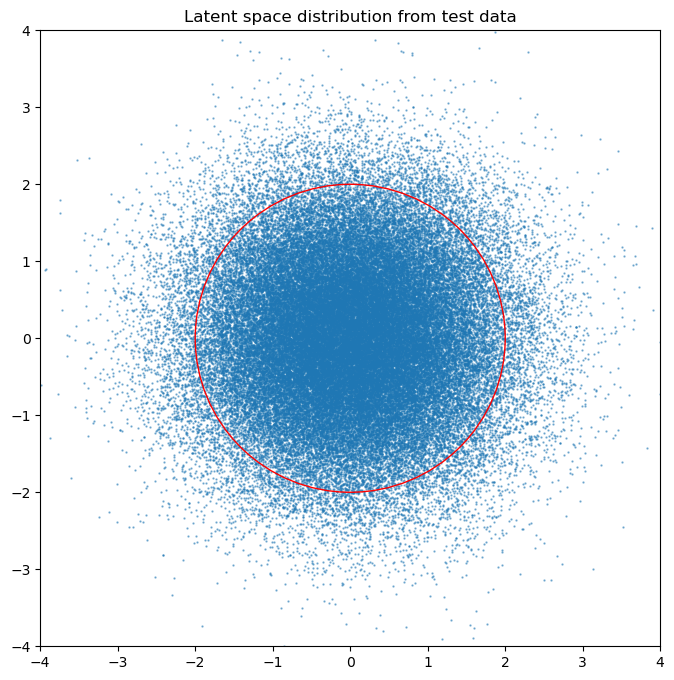

In [103]:
# Estimating mean and cov of latent space distribution
latent_mean = np.mean(np.array(z), axis=0)
latent_cov = np.cov(np.array(z), rowvar=0)


# Extracting principal components
pca = PCA(n_components=8)
pca.fit(z)
print('Explained variance distribution:\n', pca.explained_variance_ratio_)

lax = 4

fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(z[inds, 0], z[inds, 1], s=0.5, alpha=0.5)
circle1 = plt.Circle((0, 0), 2, color='r', fill=False)
ax.add_patch(circle1)
ax.set_xlim([-lax, lax])
ax.set_ylim([-lax, lax])
ax.set_title('Latent space distribution from test data')
fig.show()